# 07. 하나의 분포 모델: 범위·방향·신호를 한 곳에서

03–05의 결론은 셋이었다. 가격 수준(수익률 크기)은 현재가 유지를 넘지 못했고, 변동폭은 HAR이 기준선을 넘었으며, 방향에는 약한 신호만 있었다. 지금 서비스는 이것을 서로 다른 모델로 낸다(수익률 모델 × λ, HAR × k, 방향 분류기). 그래서 예측 가격·범위·상승 확률이 서로 어긋날 수 있다.

구매 결정에 필요한 것은 정확한 미래 가격이 아니라 앞으로의 가격 범위와 대략적인 방향이다(2026-10-05 사용자 결정). 이 노트북은 지평마다 모델 하나가 h거래일 뒤 로그수익률의 분포를 내게 한다.

y = μ(x) + σ(x) · Z

- **중심 μ(x) = w·x**: 방향. 피처 67개의 선형 결합(L2 벌점 α_μ). 절편이 없어 피처가 학습 구간 평균이면 현재가 유지다.
- **폭 log σ(x) = b + u·HAR + v·x**: 변동폭. HAR 입력(log_vol_5·20·60, 벌점 없음) + 피처 67개(L2 벌점 α_σ).
- **모양 Z**: 표본 밖 표준화 잔차 (y − μ)/σ의 분포에서 중앙값을 0으로 맞춘 것. 꼬리와 비대칭만 담는다.
- **학습**: 정규분포 CRPS의 합 + 벌점을 L-BFGS로 최소화한다(`coffee.models.DistributionModel`). CRPS는 예측 분포 전체와 실제 값의 거리이고, 예측이 점 하나면 절대오차가 된다.
- **출력**: 80% 범위 = 10%·90% 분위수, 가운데 가격 = 50% 분위수, 상승 확률 = P(y > 0), 신호 = 상승 확률 ≥ 기준이면 '구매', ≤ 1 − 기준이면 '미루기', 그 사이는 '보류', 위험 수준 = σ의 최근 3년 백분위.

## v1 기록 (2026-10-05 20:50 등록, SHA-256 b67d6b9ca2704070, 실패)

v1은 중심에 절편이 있었고(μ = a + w·x), 모양은 학습 행 잔차였으며, 입력을 자르지 않았다. 등록한 규칙대로 실행한 개발 Test에서 B1(현재가 + HAR 폭) 대비 CRPS는 5일 +0.61% [+0.21, +1.02], 20일 +1.86% [+0.81, +2.97]였다. 60일은 2013-08-12 한 행의 폭이 σ = 61,083으로 터져 평균이 의미를 잃었다(+9,327%). 상승 확률 AUC는 0.46 / 0.41 / 0.30이었다. 결과를 본 뒤의 진단에서 원인 셋을 찾았다.

1. Yahoo 페소 환율의 잘못된 시세(2013-07-12 종가 3.67 등 17개)가 20·60일 변화 피처에서 표준화 값 148이 되어 폭의 지수식을 터뜨렸다. 지금 서비스 모델은 페소 피처를 쓰지 않는다.
2. 절편이 학습 구간의 평균 추세(20·60일 연 −2% 안팎)를 미래에 그대로 적용했다. 절편을 빼면 '+변동성(HAR)' 단계의 B1 대비 CRPS가 +0.59 / +1.87 / +3.85%에서 +0.34 / +1.01 / −0.02%로 줄었다.
3. 학습 행 잔차로 만든 모양이 표본 밖보다 좁아 80% 범위 적중률이 77%에 그쳤다.

아래 v2의 변경은 이 결과를 보고 정했다. 그래서 v2의 개발 Test는 같은 구간을 두 번째로 보는 시험이다(03 → 03b와 같은 처지).

## v2 사전 등록 (계산 전에 고정, 2026-10-06)

**v1에서 바꾼 것**
- 이상치: 피처 원자료 가운데 환율·WTI·운임·ENSO·기온은 하루 변화가 그 전까지의 변화로 만든 IQR 울타리 20배 밖이면 직전 값으로 바꾼다(`coffee.features.clean_sources`, 사용자 결정). 커피 가격·금리·강수는 그대로 두고, 강수는 음수만 바꾼다. 지금 자료에서 피처가 바뀌는 곳은 페소 변화 두 개(cop_chg_20·60)의 34행씩이다.
- 중심: 절편을 뺐다(위 설명).
- 모양: 평가 연도 Y마다 같은 후보가 2009 … Y−1년에 낸 표본 밖 표준화 잔차(목표일이 Y−1년 말 이전인 행)로 만든다. 그런 잔차가 200개보다 적은 첫 해들은 학습 행 잔차를 쓴다. 서비스 모델의 모양은 같은 방법으로 2009–2025년의 표본 밖 잔차다.
- 입력: 표준화한 피처를 ±5에서 자른다.
- 매수 기준: 개발 Test에서 {0.52, 0.55, 0.58, 0.60, 0.65} 가운데 신호 빈도가 20% 이상이고, 신호 적중률이 같은 날 늘 '구매'라고 했을 때의 적중률보다 높은 값 중 적중률이 가장 높은 값이다. 그런 값이 없으면 신호를 내지 않는다(늘 '보류').

**v1과 같은 것**
- 피처 67개(기존 46개, 03b의 20개, 뉴스 점수 1개)를 중심과 폭에 모두 넣는다. 뉴스 점수는 보관 기사 1,446건의 Jev 점수를 발행 + 1일에 안다고 가정하고(개발 기록 24), 기사가 없는 날과 2022년 이전은 0이다.
- 행: 03b와 같다(기존 46개와 03b 20개 피처가 직전 60거래일 동안 모두 있는 행). 기준선도 같은 행에서 계산한다.
- 평가 구간: 개발 Test 2012–2021년(판단 기준), 재사용 확인 2022–2025년(기록만), 2026년(목표일이 확인된 행).
- 고르는 방법: 평가 연도 Y마다 안쪽 검증(2009 … Y−1년, 목표일이 Y−1년 말 이전)의 평균 CRPS가 가장 낮은 벌점 조합. 후보는 α_μ ∈ {10², 10³, 10⁴, 10⁵} × α_σ ∈ {10², 10³, 10⁴, 10⁵}의 16개이고, 서비스 설정은 Y = 2026의 선택이다.
- 기준선(같은 행, 해마다 다시 학습): B1 현재가 + HAR 폭(중심 0, σ = k · HAR 예측 일간 변동성 · √h인 정규분포), B2 지금 서비스(중심 = 03b의 연도별 선택 × λ, 폭은 B1과 같음, 상승 확률은 03의 분류기, 기준 52 / 58 / 60%). k는 04가 개발 구간에서 정한 값이라 개발 Test 비교에서 기준선에 유리하다.
- 지표: 주 지표 CRPS(낮을수록 좋다). 보조 지표 80% 범위 적중률과 평균 폭, 상승 확률의 Brier·AUC, 신호 빈도·적중률, 20거래일 구매 비용(03과 같은 시뮬레이션).

**판단 규칙**
- 사용자 결정에 따라 이 모델이 서비스의 범위·가운데 가격·상승 확률·신호·위험 수준을 모두 대신한다. 성적과 관계없이 교체하고, 성적은 화면에 그대로 표시한다.
- 'B1(또는 B2)보다 낫다'는 개발 Test의 CRPS 차이(블록 bootstrap, 블록 = h, 1,000회) 95% 구간 상한이 0보다 작을 때만 쓴다. 상승 확률은 Brier·AUC를 B2 분류기와 나란히 적는다.
- 설명용 분석(이 결과로 후보·피처·규칙을 바꾸지 않는다): 단계별 기여(무조건 분포 → +변동성(HAR) → +폭에 모든 피처 → +중심에 모든 피처 → +뉴스(서비스), 단계마다 같은 규칙으로 벌점 선택), 묶음 하나씩 빼기(서비스 모델의 연도별 벌점을 두고 묶음 하나를 중심과 폭에서 함께 뺌), 2026년 서비스 모델의 표준화 계수.
- 뉴스는 개발 Test에서 늘 0이다. 뉴스의 효과는 재사용 확인과 2026년에만 나타나고, 판단에 쓰지 않는다.
- 결과를 본 뒤에는 후보·규칙·구간을 바꾸지 않는다. 바꿀 일이 생기면 다음 버전에서 새로 등록한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common
from coffee.config import DEV_YEARS, HOLDOUT_YEARS, HORIZONS
from coffee.evaluate import (FIRST_INNER_YEAR, block_bootstrap_mean_diff, crps_normal, direction_metrics, fold_rows,
                             select_by_score, walk_forward_residuals)
from coffee.features import (ALL_FEATURES, EXTRA_FEATURES, EXTRA_GROUPS, FEATURE_GROUPS, NEWS_FEATURES, add_news,
                             build_dataset)
from coffee.models import (HAR_FEATURES, Z80, DistributionModel, LightGBMClassifier, RidgeModel, ShrunkProbability,
                           return_model)
from coffee.news import load_jev_archive
from coffee.sources import load_sources

data = add_news(build_dataset(load_sources()), load_jev_archive(), mode="research")
ROW_FEATURES = ALL_FEATURES + EXTRA_FEATURES  # 03b와 같은 행
FEATURES = ROW_FEATURES + NEWS_FEATURES       # 중심과 폭에 모두 넣는 67개
YEARS = range(FIRST_INNER_YEAR, 2027)         # 2009–2026년을 해마다 그 전까지의 자료로 예측한다
OUTER_YEARS = range(DEV_YEARS[0], 2027)       # 2012–2026년을 해마다 고른다
GRID = (1e2, 1e3, 1e4, 1e5)
MIN_SHAPE = 200                               # 표본 밖 잔차가 이보다 적은 첫 해들은 학습 행 잔차로 모양을 만든다
PERIODS = {"개발 Test": (DEV_YEARS[0], DEV_YEARS[-1]), "재사용 확인": (HOLDOUT_YEARS[0], HOLDOUT_YEARS[-1]),
           "2026년": (2026, 2026)}
news_days = data.index[data["news_score"] != 0]
print(f"자료 {data.index[0]:%Y-%m-%d} ~ {data.index[-1]:%Y-%m-%d}, 피처 {len(FEATURES)}개")
print(f"뉴스 점수가 있는 거래일 {len(news_days):,}일 ({news_days[0]:%Y-%m-%d} ~ {news_days[-1]:%Y-%m-%d})")

자료 2005-01-03 ~ 2026-10-02, 피처 67개
뉴스 점수가 있는 거래일 835일 (2022-01-10 ~ 2026-09-28)


## 1. 후보와 연도별 예측

후보마다 2009–2026년을 해마다 그 전까지의 자료로 학습해, 그해 행마다 분포(μ, σ, 80% 범위, 가운데, 상승 확률)와 CRPS를 계산해 둔다. 그해의 모양은 같은 후보가 앞선 해들에 낸 표본 밖 잔차로 맞춘다. 한 해의 예측은 그 뒤의 선택과 상관없으므로 한 번 계산해 연도별 선택에 다시 쓴다.

In [2]:
def walk_forward(make, h, years=YEARS):
    """years마다 그 전까지의 자료로 학습해 그해 행의 분포를 낸다(행 번호 → 열). make(year)가 모델을 만든다.

    모양은 앞선 해들의 표본 밖 표준화 잔차(목표일이 전년 말 이전인 행)로 맞춘다.
    """
    y, target_date = data[f"y_{h}"].to_numpy(), data[f"target_date_{h}"].to_numpy()
    parts, residuals = [], pd.Series(dtype=float)
    for year in years:
        fit, test = fold_rows(data, ROW_FEATURES, h, year, 2026)
        model = make(year).fit(data, fit, y[fit])
        known = residuals[target_date[residuals.index] <= pd.Timestamp(f"{year - 1}-12-31")]
        if len(known) >= MIN_SHAPE:
            model.calibrate(known)
        mu, sigma = model.distribution(data, test)
        low, mid, high = model.quantiles(data, test).T
        part = pd.DataFrame({"mu": mu, "sigma": sigma, "low": low, "mid": mid, "high": high,
                             "prob_up": model.prob_up(data, test), "crps": model.crps(data, test, y[test]),
                             "z": model.residuals(data, test, y[test]), "base": float(np.mean(y[fit] > 0))}, index=test)
        parts.append(part)
        residuals = pd.concat([residuals, part["z"]]) if len(residuals) else part["z"]
    return pd.concat(parts)


def candidates(mean, scale, har=True):
    """벌점 조합마다 모델 설정. 피처가 없는 쪽은 벌점을 고르지 않는다."""
    out = {}
    for a_mean in (GRID if mean else (None,)):
        for a_scale in (GRID if scale else (None,)):
            center = "현재가" if a_mean is None else f"피처 α={a_mean:g}"
            width = ("HAR" if har else "상수") + ("" if a_scale is None else f" + 피처 α={a_scale:g}")
            out[f"중심 {center} | 폭 {width}"] = {"mean": mean, "scale": scale, "har": har,
                                                  "alpha_mean": a_mean or 1.0, "alpha_scale": a_scale or 1.0}
    return out


def make(c):
    return lambda year=None: DistributionModel(c["mean"], c["scale"], c["har"], c["alpha_mean"], c["alpha_scale"])


STEPS = {
    "무조건 분포": candidates([], [], har=False),
    "+변동성(HAR)": candidates([], []),
    "+폭에 모든 피처": candidates([], ROW_FEATURES),
    "+중심에 모든 피처": candidates(ROW_FEATURES, ROW_FEATURES),
    "+뉴스(서비스)": candidates(FEATURES, FEATURES),
}
FINAL = "+뉴스(서비스)"
frames = {(h, step, label): walk_forward(make(c), h)
          for h in HORIZONS for step, pool in STEPS.items() for label, c in pool.items()}
print({step: len(pool) for step, pool in STEPS.items()}, "단계별 후보 수(지평마다)")

{'무조건 분포': 1, '+변동성(HAR)': 1, '+폭에 모든 피처': 4, '+중심에 모든 피처': 16, '+뉴스(서비스)': 16} 단계별 후보 수(지평마다)


## 2. 해마다 벌점 고르기

단계마다 같은 규칙(안쪽 검증 평균 CRPS 최소)으로 고른다. 마지막 단계(+뉴스)가 서비스 모델이다.

In [3]:
def pick(by_label, selection):
    """연도별로 고른 후보의 그해 행을 이어 붙인다."""
    parts = []
    for year, label in selection["candidate"].items():
        frame = by_label[label]
        parts.append(frame[data.index[frame.index].year == year])
    return pd.concat(parts)


selections, outer = {}, {}
for h in HORIZONS:
    for step, pool in STEPS.items():
        by_label = {label: frames[h, step, label] for label in pool}
        selections[h, step] = select_by_score(data, h, {label: f["crps"] for label, f in by_label.items()}, OUTER_YEARS)
        outer[h, step] = pick(by_label, selections[h, step])
chosen = pd.DataFrame({f"{h}거래일": selections[h, FINAL]["candidate"] for h in HORIZONS})
chosen.index.name = "평가 연도"
chosen

,5거래일,20거래일,60거래일
평가 연도,,,
2012,중심 피처 α=100000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2013,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2014,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2015,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2016,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2017,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2018,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2019,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=10000
2020,중심 피처 α=10000 | 폭 HAR + 피처 α=100000,중심 피처 α=10000 | 폭 HAR + 피처 α=10000,중심 피처 α=100000 | 폭 HAR + 피처 α=100000


## 3. 기준선

B1(현재가 + HAR 폭)과 B2(지금 서비스)를 같은 행에서 해마다 다시 학습한다. B2의 중심은 03b의 연도별 선택 × λ, 상승 확률은 03의 분류기다.

In [4]:
K = {int(h): v["interval_multiplier"] for h, v in common.load_result("volatility_selection").items()}
redesign = {int(h): v for h, v in common.load_result("return_redesign")["horizons"].items()}
direction_choice = {int(h): v for h, v in common.load_result("direction_selection").items()}
B1, B2 = "B1 현재가 + HAR 폭", "B2 지금 서비스"


def baselines(h):
    y = data[f"y_{h}"].to_numpy()
    b1, b2 = [], []
    for year in OUTER_YEARS:
        fit, test = fold_rows(data, ROW_FEATURES, h, year, 2026)
        vol_fit, _ = fold_rows(data, ALL_FEATURES, h, year, 2026, target=f"v_{h}")
        har = RidgeModel(HAR_FEATURES, alpha=1).fit(data, vol_fit, data[f"v_{h}"].to_numpy()[vol_fit])
        sigma = K[h] * np.exp(har.predict(data, test)) * np.sqrt(h)
        c = redesign[h]["by_year"][str(year)]
        center = np.zeros(len(test)) if c["candidate"] == "Naive" else c["weight"] * return_model(
            c["model"], c["features"], h, c["params"], c["scale"]).fit(data, fit, y[fit]).predict(data, test)
        d = direction_choice[h]
        direction_fit, _ = fold_rows(data, ALL_FEATURES, h, year, 2026)
        classifier = ShrunkProbability(LightGBMClassifier(d["features"], n_estimators=200, min_child_samples=80),
                                       d["shrink"]).fit(data, direction_fit, y[direction_fit])
        for out, mu, prob in ((b1, np.zeros(len(test)), np.nan), (b2, center, classifier.predict(data, test))):
            out.append(pd.DataFrame({"mu": mu, "sigma": sigma, "low": mu - Z80 * sigma, "mid": mu,
                                     "high": mu + Z80 * sigma, "prob_up": prob, "crps": crps_normal(y[test], mu, sigma),
                                     "base": classifier.base_}, index=test))
    return pd.concat(b1), pd.concat(b2)


assert all(redesign[h]["adopted"] for h in HORIZONS)
for h in HORIZONS:
    outer[h, B1], outer[h, B2] = baselines(h)
    assert outer[h, B1].index.equals(outer[h, FINAL].index)  # 모든 비교가 같은 행
print("기준선 준비")

기준선 준비


## 4. 결과

개발 Test가 판단 기준이다. 재사용 확인과 2026년은 이미 본 구간이라 참고로 적는다. CRPS 변화는 B1 대비 %(음수면 더 좋음)다.

In [5]:
def period_rows(h, period, index):
    first, last = PERIODS[period]
    origin, target = data.index[index], data[f"target_date_{h}"].to_numpy()[index]
    return index[(origin.year >= first) & (origin.year <= last) & (target <= pd.Timestamp(f"{last}-12-31"))]


def score(h, name, period, against=B1):
    """name의 CRPS와 against 대비 변화(%, 블록 bootstrap 95% 구간), 80% 범위 적중률·폭."""
    rows = period_rows(h, period, outer[h, against].index)
    f, base = outer[h, name].loc[rows], outer[h, against].loc[rows]
    y = data[f"y_{h}"].to_numpy()[rows]
    ci, scale = block_bootstrap_mean_diff(f["crps"], base["crps"], block=h), base["crps"].mean()
    return {"행": len(rows), "CRPS": f["crps"].mean(), "변화 %": 100 * ci["diff"] / scale,
            "95% 하한": 100 * ci["low"] / scale, "95% 상한": 100 * ci["high"] / scale,
            "80% 적중률": float(np.mean((y >= f["low"]) & (y <= f["high"]))),
            "80% 폭(%)": 100 * float(np.mean(np.exp(f["high"]) - np.exp(f["low"])))}


main = []
for h in HORIZONS:
    for period in PERIODS:
        for name in (FINAL, B2, B1):
            s = score(h, name, period)
            row = {"지평": h, "구간": period, "모델": "분포 모델(서비스)" if name == FINAL else name, "행": s["행"],
                   "CRPS": s["CRPS"], "B1 대비 %": s["변화 %"], "B1 대비 95% 구간": f"[{s['95% 하한']:+.2f}, {s['95% 상한']:+.2f}]",
                   "80% 적중률": s["80% 적중률"], "80% 폭(%)": s["80% 폭(%)"]}
            if name == FINAL:
                s2 = score(h, FINAL, period, against=B2)
                row.update({"B2 대비 %": s2["변화 %"], "B2 대비 95% 구간": f"[{s2['95% 하한']:+.2f}, {s2['95% 상한']:+.2f}]"})
            main.append(row)
main = pd.DataFrame(main)
main.set_index(["지평", "구간", "모델"]).round(4)

행    CRPS  B1 대비 %     B1 대비 95% 구간  80% 적중률  \
지평 구간      모델                                                                
5  개발 Test 분포 모델(서비스)      2385  0.0251   0.2222   [-0.18, +0.61]   0.8273   
           B2 지금 서비스       2385  0.0251  -0.0064   [-0.47, +0.48]   0.8004   
           B1 현재가 + HAR 폭  2385  0.0251   0.0000   [+0.00, +0.00]   0.7983   
   재사용 확인  분포 모델(서비스)       871  0.0288  -0.3259   [-0.90, +0.26]   0.7819   
           B2 지금 서비스        871  0.0289  -0.1676   [-0.88, +0.61]   0.7819   
           B1 현재가 + HAR 폭   871  0.0289   0.0000   [+0.00, +0.00]   0.7796   
   2026년   분포 모델(서비스)       184  0.0326   0.0194   [-1.66, +1.69]   0.7554   
           B2 지금 서비스        184  0.0327   0.1366   [-1.12, +1.47]   0.7609   
           B1 현재가 + HAR 폭   184  0.0326   0.0000   [+0.00, +0.00]   0.7663   
20 개발 Test 분포 모델(서비스)      2370  0.0478   1.3589   [+0.06, +2.56]   0.8245   
           B2 지금 서비스       2370  0.0468  -0.6989   [-2.64, +1.51]   0.7992   
           B1 현재가 + HAR 폭  2370  0.0471   0.0000   [+0.00, +0.00]   0.7987   
   재사용 확인  분포 모델(서비스)       856  0.0570  -1.1319   [-3.05, +0.64]   0.7897   
           B2 지금 서비스        856  0.0574  -0.4257   [-2.47, +1.61]   0.7500   
           B1 현재가 + HAR 폭   856  0.0576   0.0000   [+0.00, +0.00]   0.7675   
   2026년   분포 모델(서비스)       169  0.0801   0.4472   [-4.29, +4.88]   0.6154   
           B2 지금 서비스        169  0.0799   0.1641   [-2.20, +2.71]   0.6154   
           B1 현재가 + HAR 폭   169  0.0797   0.0000   [+0.00, +0.00]   0.6213   
60 개발 Test 분포 모델(서비스)      2330  0.0721   2.0777   [-0.37, +4.42]   0.8215   
           B2 지금 서비스       2330  0.0730   3.3514   [+0.82, +6.34]   0.8039   
           B1 현재가 + HAR 폭  2330  0.0706   0.0000   [+0.00, +0.00]   0.8163   
   재사용 확인  분포 모델(서비스)       816  0.0883  -2.8345   [-8.87, +2.06]   0.7426   
           B2 지금 서비스        816  0.0907  -0.1692   [-0.57, +0.25]   0.7243   
           B1 현재가 + HAR 폭   816  0.0909   0.0000   [+0.00, +0.00]   0.7243   
   2026년   분포 모델(서비스)       129  0.0834  -8.8112  [-15.31, -2.90]   0.7597   
           B2 지금 서비스        129  0.0902  -1.3551   [-3.79, +0.92]   0.7209   
           B1 현재가 + HAR 폭   129  0.0914   0.0000   [+0.00, +0.00]   0.7442   

                           80% 폭(%)  B2 대비 %     B2 대비 95% 구간  
지평 구간      모델                                                  
5  개발 Test 분포 모델(서비스)       11.8313   0.2287   [-0.35, +0.78]  
           B2 지금 서비스        11.3386      NaN              NaN  
           B1 현재가 + HAR 폭   11.3438      NaN              NaN  
   재사용 확인  분포 모델(서비스)       12.5211  -0.1586   [-0.85, +0.52]  
           B2 지금 서비스        12.6077      NaN              NaN  
           B1 현재가 + HAR 폭   12.6101      NaN              NaN  
   2026년   분포 모델(서비스)       13.5057  -0.1170   [-1.53, +1.23]  
           B2 지금 서비스        13.6055      NaN              NaN  
           B1 현재가 + HAR 폭   13.6151      NaN              NaN  
20 개발 Test 분포 모델(서비스)       23.6852   2.0722   [-0.28, +4.13]  
           B2 지금 서비스        20.8633      NaN              NaN  
           B1 현재가 + HAR 폭   20.9217      NaN              NaN  
   재사용 확인  분포 모델(서비스)       24.6065  -0.7092   [-2.78, +1.28]  
           B2 지금 서비스        23.0935      NaN              NaN  
           B1 현재가 + HAR 폭   23.1513      NaN              NaN  
   2026년   분포 모델(서비스)       25.6381   0.2826   [-3.73, +3.81]  
           B2 지금 서비스        24.3322      NaN              NaN  
           B1 현재가 + HAR 폭   24.3875      NaN              NaN  
60 개발 Test 분포 모델(서비스)       37.1123  -1.2323   [-5.55, +2.55]  
           B2 지금 서비스        33.7987      NaN              NaN  
           B1 현재가 + HAR 폭   33.7788      NaN              NaN  
   재사용 확인  분포 모델(서비스)       37.5848  -2.6698   [-8.50, +2.19]  
           B2 지금 서비스        37.0199      NaN              NaN  
           B1 현재가 + HAR 폭   37.0458      NaN              NaN  
   2026년   분포 모델(서비스)       36.8549  -7.5585  [-11.81, -3.64]  
           B2 지금 서비스        36.7690    

개발 Test에서 분포 모델은 B1보다 5일 +0.2% [−0.2, +0.6], 20일 +1.4% [+0.1, +2.6], 60일 +2.1% [−0.4, +4.4]였다. 기준선보다 낫다고 할 수 있는 지평은 없고, 20일은 구간이 0보다 위에 있어 조금 나쁘다. 이전 서비스(B2)와 비교하면 5일 +0.2%, 20일 +2.1%, 60일 −1.2%다.

80% 범위는 실제 가격을 82–83% 담아 목표(80%)보다 조금 넓고, 평균 폭도 B1보다 넓다(5일 11.8 대 11.3%, 20일 23.7 대 20.9%, 60일 37.1 대 33.8%). 표본 밖 잔차가 학습 행 잔차보다 넓다는 v1의 진단과 같은 방향이다. 재사용 확인(2022–2025)에서는 B1 대비 −0.3 / −1.1 / −2.8%로 조금 나았지만 이미 본 구간이다.

In [6]:
ladder = pd.DataFrame([{"지평": h, "단계": step,
                        **{f"{period} B1 대비 %": score(h, step, period)["변화 %"] for period in PERIODS},
                        "개발 95% 구간": "[{0:+.2f}, {1:+.2f}]".format(*(score(h, step, "개발 Test")[k] for k in ("95% 하한", "95% 상한"))),
                        "개발 80% 적중률": score(h, step, "개발 Test")["80% 적중률"]}
                       for h in HORIZONS for step in STEPS])
ladder.set_index(["지평", "단계"]).round(2)

개발 Test B1 대비 %  재사용 확인 B1 대비 %  2026년 B1 대비 %       개발 95% 구간  \
지평 단계                                                                           
5  무조건 분포                 0.46           -0.31           0.18  [+0.02, +0.86]   
   +변동성(HAR)              0.34           -0.21          -0.27  [+0.01, +0.66]   
   +폭에 모든 피처              0.34           -0.21          -0.28  [+0.01, +0.66]   
   +중심에 모든 피처             0.22           -0.33           0.00  [-0.18, +0.61]   
   +뉴스(서비스)               0.22           -0.33           0.02  [-0.18, +0.61]   
20 무조건 분포                 1.18           -0.22           0.51  [+0.27, +2.13]   
   +변동성(HAR)              1.77            0.05           0.17  [+0.74, +2.81]   
   +폭에 모든 피처              1.82            0.05           0.20  [+0.77, +2.89]   
   +중심에 모든 피처             1.36           -1.16           0.42  [+0.06, +2.56]   
   +뉴스(서비스)               1.36           -1.13           0.45  [+0.06, +2.56]   
60 무조건 분포                 2.18            0.71          -0.71  [+0.36, +3.99]   
   +변동성(HAR)              2.13            0.28          -1.50  [-0.07, +4.26]   
   +폭에 모든 피처              2.22            0.45          -1.05  [-0.12, +4.49]   
   +중심에 모든 피처             2.08           -2.86          -8.76  [-0.37, +4.42]   
   +뉴스(서비스)               2.08           -2.83          -8.81  [-0.37, +4.42]   

               개발 80% 적중률  
지평 단계                      
5  무조건 분포            0.82  
   +변동성(HAR)         0.83  
   +폭에 모든 피처         0.83  
   +중심에 모든 피처        0.83  
   +뉴스(서비스)          0.83  
20 무조건 분포            0.80  
   +변동성(HAR)         0.83  
   +폭에 모든 피처         0.83  
   +중심에 모든 피처        0.82  
   +뉴스(서비스)          0.82  
60 무조건 분포            0.81  
   +변동성(HAR)         0.83  
   +폭에 모든 피처         0.82  
   +중심에 모든 피처        0.82  
   +뉴스(서비스)          0.82

단계별로 보면 '무조건 분포'부터 이미 B1보다 나쁘다(+0.5 / +1.2 / +2.2%). B1의 배율 k는 개발 구간에서 맞춘 값이라 이 비교에서 유리하다. HAR 폭은 5일에서만 뚜렷하게 도왔고(−0.12%p) 20일은 오히려 나빠졌다(+0.59%p). 중심에 피처를 넣자 5일 −0.12%p, 20일 −0.46%p, 60일 −0.14%p 좋아졌다. 폭에 피처를 넣은 효과와 뉴스의 효과는 0.1%p 안쪽이었다.

## 5. 상승 확률과 매수 신호

매수 기준은 개발 Test에서 정한다. 신호 빈도 20% 이상이고 신호 적중률이 같은 날 늘 '구매'라고 했을 때보다 높은 기준만 인정하고, 없으면 신호를 내지 않는다(기준 '없음'). B2(03의 분류기)는 원래 기준(52 / 58 / 60%)을 쓴다.

In [7]:
THRESHOLDS = (0.52, 0.55, 0.58, 0.60, 0.65)
NEVER = 1.0  # 기준 없음: 확률이 1 이상이거나 0 이하일 때만 신호라 사실상 늘 '보류'


def direction(h, name, period, threshold):
    rows = period_rows(h, period, outer[h, name].index)
    f = outer[h, name].loc[rows]
    return direction_metrics(data[f"y_{h}"].to_numpy()[rows], f["prob_up"], base_rate=f["base"].mean(),
                             threshold=NEVER if threshold is None else threshold)


threshold = {}
for h in HORIZONS:
    qualified = {}
    for t in THRESHOLDS:
        d = direction(h, FINAL, "개발 Test", t)
        if d["coverage"] >= 0.2 and d["precision"] > d["signal_up_rate"]:
            qualified[t] = d["precision"]
    threshold[h] = max(qualified, key=qualified.get) if qualified else None
print("매수 기준:", threshold)

direction_rows = []
for h in HORIZONS:
    for period in PERIODS:
        for name, t in ((FINAL, threshold[h]), (B2, direction_choice[h]["threshold"])):
            d = direction(h, name, period, t)
            direction_rows.append({"지평": h, "구간": period, "모델": "분포 모델(서비스)" if name == FINAL else name,
                                   "기준": "없음" if t is None else t, "AUC": d["auc"], "Brier": d["brier"],
                                   "기본 비율 Brier": d["base_brier"], "신호 빈도": d["coverage"],
                                   "신호 적중률": d["precision"], "같은 날 늘 구매": d["signal_up_rate"],
                                   "실제 상승 비율": d["up_rate"]})
direction_table = pd.DataFrame(direction_rows)
direction_table.set_index(["지평", "구간", "모델"]).round(3)

매수 기준: {5: None, 20: 0.52, 60: None}


기준    AUC  Brier  기본 비율 Brier  신호 빈도  신호 적중률  \
지평 구간      모델                                                           
5  개발 Test 분포 모델(서비스)    없음  0.532  0.250        0.250  0.000     NaN   
           B2 지금 서비스   0.52  0.534  0.249        0.250  0.575   0.540   
   재사용 확인  분포 모델(서비스)    없음  0.521  0.249        0.250  0.000     NaN   
           B2 지금 서비스   0.52  0.531  0.249        0.250  0.627   0.546   
   2026년   분포 모델(서비스)    없음  0.463  0.251        0.249  0.000     NaN   
           B2 지금 서비스   0.52  0.512  0.249        0.249  0.380   0.543   
20 개발 Test 분포 모델(서비스)  0.52  0.557  0.249        0.248  0.350   0.543   
           B2 지금 서비스   0.58  0.575  0.244        0.248  0.425   0.616   
   재사용 확인  분포 모델(서비스)  0.52  0.584  0.245        0.250  0.671   0.578   
           B2 지금 서비스   0.58  0.589  0.244        0.250  0.359   0.616   
   2026년   분포 모델(서비스)  0.52  0.515  0.249        0.250  0.515   0.529   
           B2 지금 서비스   0.58  0.390  0.263        0.250  0.201   0.412   
60 개발 Test 분포 모델(서비스)    없음  0.637  0.249        0.246  0.000     NaN   
           B2 지금 서비스    0.6  0.545  0.255        0.247  0.439   0.560   
   재사용 확인  분포 모델(서비스)    없음  0.629  0.235        0.253  0.000     NaN   
           B2 지금 서비스    0.6  0.619  0.246        0.253  0.347   0.569   
   2026년   분포 모델(서비스)    없음  0.874  0.219        0.250  0.000     NaN   
           B2 지금 서비스    0.6  0.698  0.232        0.250  0.310   0.775   

                       같은 날 늘 구매  실제 상승 비율  
지평 구간      모델                               
5  개발 Test 분포 모델(서비스)        NaN     0.472  
           B2 지금 서비스       0.469     0.472  
   재사용 확인  분포 모델(서비스)        NaN     0.491  
           B2 지금 서비스       0.506     0.491  
   2026년   분포 모델(서비스)        NaN     0.435  
           B2 지금 서비스       0.386     0.435  
20 개발 Test 분포 모델(서비스)      0.539     0.449  
           B2 지금 서비스       0.446     0.449  
   재사용 확인  분포 모델(서비스)      0.502     0.488  
           B2 지금 서비스       0.489     0.488  
   2026년   분포 모델(서비스)      0.540     0.479  
           B2 지금 서비스       0.529     0.479  
60 개발 Test 분포 모델(서비스)        NaN     0.418  
           B2 지금 서비스       0.277     0.418  
   재사용 확인  분포 모델(서비스)        NaN     0.556  
           B2 지금 서비스       0.484     0.556  
   2026년   분포 모델(서비스)        NaN     0.465  
           B2 지금 서비스       0.325     0.465

In [8]:
def purchase(name, period, t, h=20):
    """03과 같은 시뮬레이션: 20거래일마다 '미루기' 신호면 20거래일 뒤에, 아니면 지금 산다(정기 구매 대비 %)."""
    rows = period_rows(h, period, outer[h, name].index)[::h]
    now = data["close"].to_numpy()[rows]
    later = now * np.exp(data[f"y_{h}"].to_numpy()[rows])
    wait = outer[h, name].loc[rows, "prob_up"].to_numpy() <= 1 - (NEVER if t is None else t)
    return {"결정 수": len(rows), "미루기 수": int(wait.sum()),
            "모델 신호 %": 100 * float(np.mean(np.where(wait, later, now) / now - 1)),
            "무작위 %": 100 * float(np.mean((now + later) / 2 / now - 1)),
            "오라클 %": 100 * float(np.mean(np.minimum(now, later) / now - 1))}


purchase_table = pd.DataFrame([{"구간": period, "모델": "분포 모델(서비스)" if name == FINAL else name, **purchase(name, period, t)}
                               for period in PERIODS for name, t in ((FINAL, threshold[20]), (B2, direction_choice[20]["threshold"]))])
purchase_table.set_index(["구간", "모델"]).round(2)

결정 수  미루기 수  모델 신호 %  무작위 %  오라클 %
구간      모델                                            
개발 Test 분포 모델(서비스)   119     18    -0.16   0.03  -3.34
        B2 지금 서비스    119     35    -0.38   0.03  -3.34
재사용 확인  분포 모델(서비스)    43     18    -0.79   0.54  -3.44
        B2 지금 서비스     43     14     0.10   0.54  -3.44
2026년   분포 모델(서비스)     9      2    -0.87  -1.02  -6.52
        B2 지금 서비스      9      2     3.29  -1.02  -6.52

상승 확률의 AUC는 0.53 / 0.56 / 0.64로 이전 분류기(0.53 / 0.58 / 0.55)와 비슷하거나 60일에서 조금 높았다. 하지만 확률이 50% 가까이에 몰려, 신호 빈도 20% 이상이면서 같은 날 늘 구매하는 것보다 적중률이 높은 기준은 20일의 52%(적중률 54.3% 대 53.9%)뿐이었다. 5·60일은 신호를 내지 않는다. 20일 신호대로 산 비용은 정기 구매 대비 개발 −0.16%, 재사용 −0.79%로 이전 서비스(−0.38%, +0.10%)와 비슷하고, 미래를 아는 경우(−3.3%)에는 크게 못 미친다.

## 6. 무엇이 방향을, 무엇이 폭을 움직였나

묶음 하나씩 빼기는 서비스 모델의 연도별 벌점을 그대로 두고 그 묶음을 중심과 폭에서 함께 뺀 모델과 비교한다(2009–2011년은 2012년의 벌점을 쓴다). 값은 서비스 모델 대비 CRPS 변화(%)이고, 양수면 그 묶음을 뺐을 때 나빠졌다(그 묶음이 도움이 됐다)는 뜻이다.

In [9]:
GROUPS = {**FEATURE_GROUPS, **EXTRA_GROUPS, "news": NEWS_FEATURES}
GROUP_LABELS = {"price": "가격", "macro": "거시", "climate": "기후", "cycle": "주기", "short": "단기 위험",
                "climate_summary": "기후 요약", "macro_long": "거시(장기)", "news": "뉴스"}
alphas = {(h, year): STEPS[FINAL][selections[h, FINAL].loc[max(year, OUTER_YEARS[0]), "candidate"]]
          for h in HORIZONS for year in YEARS}
logo_rows = []
for h in HORIZONS:
    for group, names in GROUPS.items():
        keep = [name for name in FEATURES if name not in names]
        outer[h, f"−{group}"] = walk_forward(
            lambda year, keep=keep, h=h: DistributionModel(keep, keep, True, alphas[h, year]["alpha_mean"],
                                                           alphas[h, year]["alpha_scale"]), h)
        logo_rows.append({"지평": h, "뺀 묶음": GROUP_LABELS[group], "피처 수": len(names),
                          **{f"{period} CRPS 변화 %": score(h, f"−{group}", period, against=FINAL)["변화 %"] for period in PERIODS}})
leave_one_out = pd.DataFrame(logo_rows)
leave_one_out.set_index(["지평", "뺀 묶음"]).round(2)

피처 수  개발 Test CRPS 변화 %  재사용 확인 CRPS 변화 %  2026년 CRPS 변화 %
지평 뺀 묶음                                                              
5  가격         8               0.11              0.05             0.12
   거시         5              -0.02              0.01             0.13
   기후        29               0.00              0.08            -0.05
   주기         4               0.01             -0.02            -0.02
   단기 위험      2              -0.00              0.02            -0.01
   기후 요약     12               0.06             -0.03            -0.18
   거시(장기)     6               0.03              0.01            -0.10
   뉴스         1               0.00              0.00            -0.02
20 가격         8               0.28              0.23             0.85
   거시         5              -0.15              0.08             0.06
   기후        29               0.07              0.59            -0.33
   주기         4              -0.04             -0.08             0.20
   단기 위험      2              -0.07             -0.04             0.12
   기후 요약     12              -0.06              0.19            -0.10
   거시(장기)     6              -0.02              0.15            -0.18
   뉴스         1              -0.08             -0.01             0.03
60 가격         8              -0.01              0.21             1.48
   거시         5              -0.05              0.21             0.09
   기후        29              -0.00              2.06             3.98
   주기         4              -0.03              0.00             1.12
   단기 위험      2              -0.06              0.18             0.23
   기후 요약     12              -0.05              0.65             0.15
   거시(장기)     6              -0.01              0.52             1.82
   뉴스         1              -0.06              0.18             0.22

In [10]:
# 서비스 모델: 2006–2025년으로 학습하고, 모양은 2009–2025년의 표본 밖 잔차로 맞춘다(06과 같은 절차)
final_models, coef_rows = {}, []
for h in HORIZONS:
    label = selections[h, FINAL].loc[2026, "candidate"]
    c = STEPS[FINAL][label]
    residuals = walk_forward_residuals(data, make(c), ROW_FEATURES, h, range(FIRST_INNER_YEAR, 2026), 2025)
    same = frames[h, FINAL, label]["z"]
    assert np.allclose(residuals.to_numpy(), same.reindex(residuals.index).to_numpy())  # 1절의 계산과 같다
    fit, _ = fold_rows(data, ROW_FEATURES, h, 2026, 2026)
    final_models[h] = make(c)().fit(data, fit, data[f"y_{h}"].to_numpy()[fit]).calibrate(residuals)
    coef = final_models[h].coefficients()
    for head, name in (("mean", "중심(방향)"), ("scale", "폭(변동폭)")):
        for group, names in {"HAR": HAR_FEATURES, **GROUPS}.items():
            values = [abs(coef[head][n]) for n in names if n in coef[head]]
            if values:
                coef_rows.append({"지평": h, "머리": name, "묶음": GROUP_LABELS.get(group, group), "|계수| 합": sum(values)})
coef_groups = pd.DataFrame(coef_rows).pivot_table(index=["머리", "묶음"], columns="지평", values="|계수| 합", sort=False)
coef_groups.round(3)

지평                5      20     60
머리     묶음                         
중심(방향) 가격      0.029  0.060  0.046
       거시      0.012  0.017  0.026
       기후      0.068  0.164  0.284
       주기      0.007  0.012  0.028
       단기 위험   0.004  0.004  0.008
       기후 요약   0.036  0.063  0.096
       거시(장기)  0.019  0.038  0.072
       뉴스      0.001  0.002  0.001
폭(변동폭) 가격      0.002  0.012  0.010
       거시      0.000  0.006  0.008
       기후      0.003  0.035  0.073
       주기      0.001  0.008  0.015
       단기 위험   0.000  0.000  0.000
       기후 요약   0.001  0.021  0.030
       거시(장기)  0.000  0.008  0.014
       뉴스      0.000  0.001  0.001
       HAR     0.099  0.075  0.345

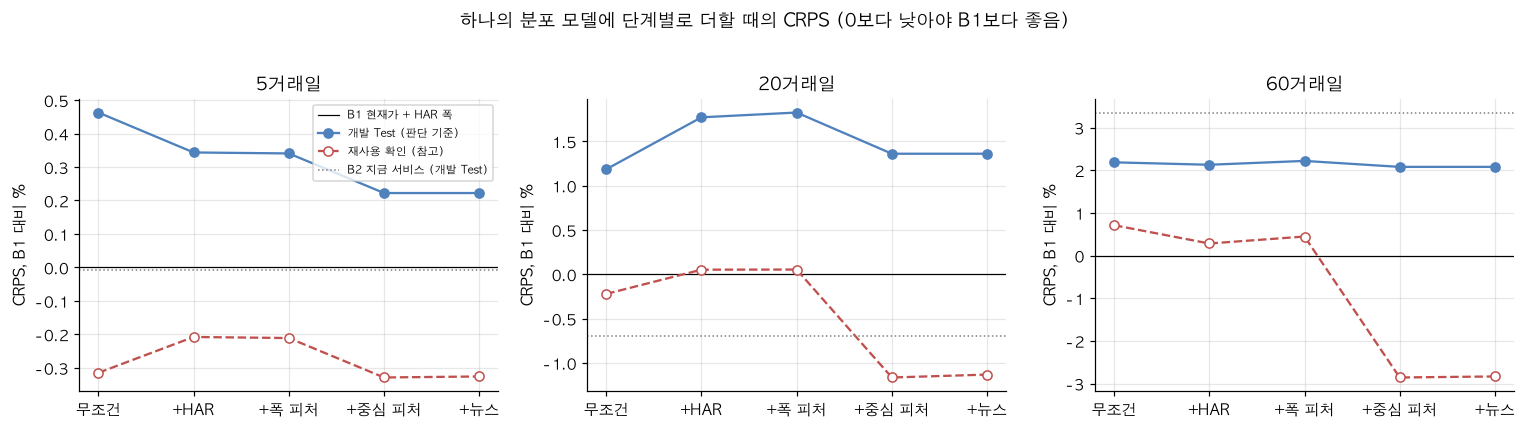

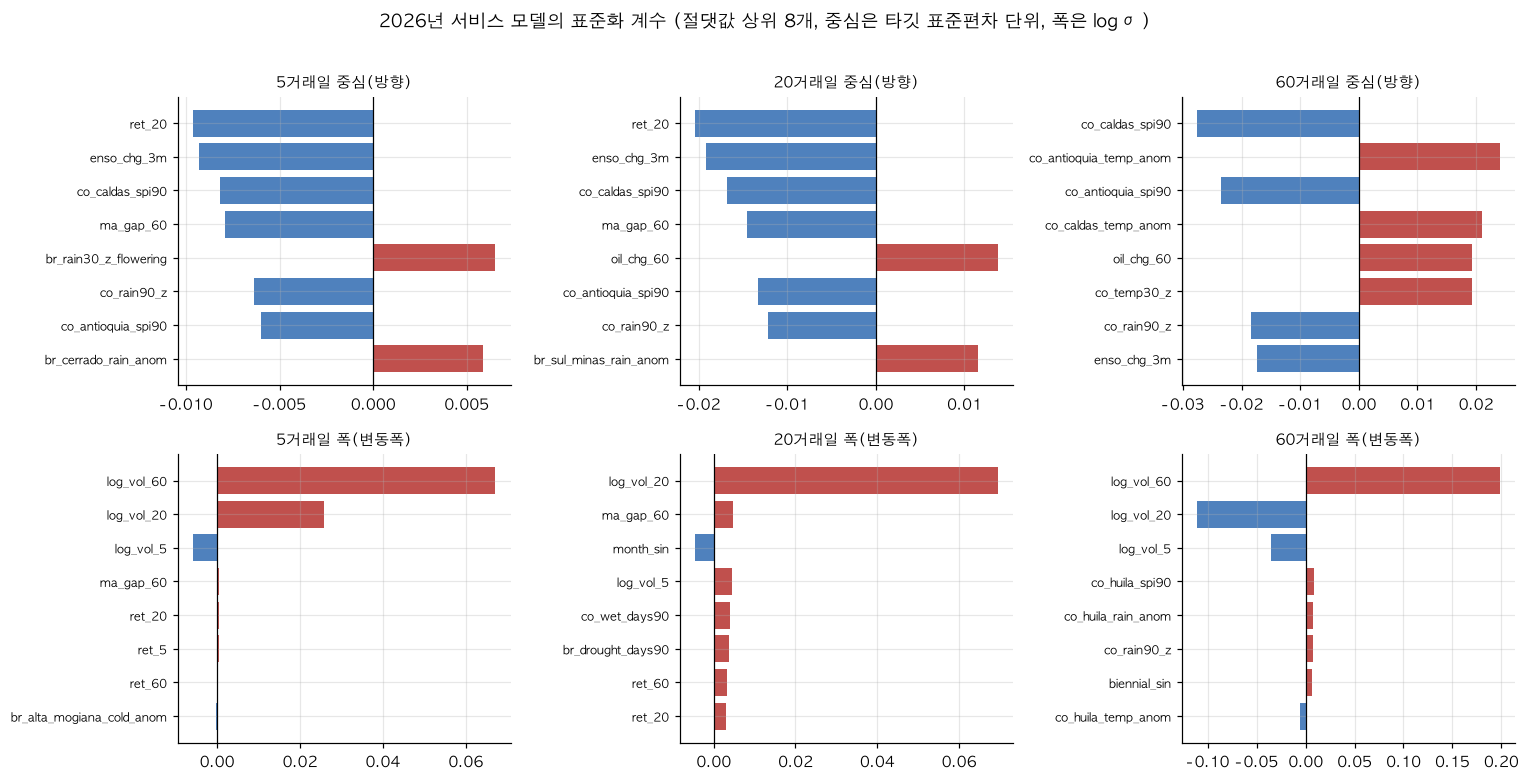

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = list(STEPS)
for ax, h in zip(axes, HORIZONS):
    table = ladder[ladder["지평"] == h].set_index("단계").loc[order]
    x = np.arange(len(order))
    ax.axhline(0, color="black", lw=0.8, label="B1 현재가 + HAR 폭")
    ax.plot(x, table["개발 Test B1 대비 %"], marker="o", color="#4f81bd", label="개발 Test (판단 기준)")
    ax.plot(x, table["재사용 확인 B1 대비 %"], marker="o", ls="--", color="#c0504d", mfc="white", label="재사용 확인 (참고)")
    ax.axhline(score(h, B2, "개발 Test")["변화 %"], color="gray", ls=":", lw=1, label="B2 지금 서비스 (개발 Test)")
    ax.set_xticks(x, ["무조건", "+HAR", "+폭 피처", "+중심 피처", "+뉴스"])
    ax.set(title=f"{h}거래일", ylabel="CRPS, B1 대비 %")
axes[0].legend(fontsize=7)
fig.suptitle("하나의 분포 모델에 단계별로 더할 때의 CRPS (0보다 낮아야 B1보다 좋음)", y=1.02)
fig.tight_layout()
common.save_fig(fig, "distribution_ladder.png")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, h in enumerate(HORIZONS):
    coef = final_models[h].coefficients()
    for row, (head, name) in enumerate((("mean", "중심(방향)"), ("scale", "폭(변동폭)"))):
        top = pd.Series(coef[head]).sort_values(key=abs).tail(8)
        axes[row, col].barh(top.index, top.to_numpy(), color=np.where(top.to_numpy() > 0, "#c0504d", "#4f81bd"))
        axes[row, col].axvline(0, color="black", lw=0.8)
        axes[row, col].set_title(f"{h}거래일 {name}", fontsize=10)
        axes[row, col].tick_params(axis="y", labelsize=8)
fig.suptitle("2026년 서비스 모델의 표준화 계수 (절댓값 상위 8개, 중심은 타깃 표준편차 단위, 폭은 log σ)", y=1.01)
fig.tight_layout()
common.save_fig(fig, "distribution_coefficients.png")
plt.show()

묶음을 하나씩 빼도 개발 Test CRPS는 ±0.3% 안쪽에서 움직였다. 가장 큰 것은 20일에서 가격을 뺐을 때(+0.28%)다. 재사용 확인에서는 기후를 빼면 60일이 2.1% 나빠졌지만 개발 구간에서는 차이가 없어, 기후가 60일 범위를 돕는다고 말할 근거는 아직 약하다. 계수로 보면 폭은 HAR이 대부분을 정하고, 중심은 여러 기후 피처에 작은 계수가 흩어져 있다. 뉴스의 계수는 거의 0이다.

## 7. 서비스 설정

2026년의 선택(안쪽 검증 2009–2025)이 서비스 설정이다. 06이 이 설정으로 2006–2025년을 학습하고 2009–2025년의 표본 밖 잔차로 모양을 맞춰 동결한다.

In [12]:
def summary(h, name, t):
    out = {}
    for period, key in (("개발 Test", "dev"), ("재사용 확인", "holdout"), ("2026년", "forward")):
        s, s2 = score(h, name, period), score(h, name, period, against=B2)
        d = direction(h, name, period, t)
        out[key] = {"rows": s["행"], "crps": s["CRPS"], "crps_vs_b1_pct": s["변화 %"], "b1_ci_low_pct": s["95% 하한"],
                    "b1_ci_high_pct": s["95% 상한"], "crps_vs_b2_pct": s2["변화 %"], "b2_ci_low_pct": s2["95% 하한"],
                    "b2_ci_high_pct": s2["95% 상한"], "coverage80": s["80% 적중률"], "width80_pct": s["80% 폭(%)"],
                    "auc": d["auc"], "brier": d["brier"], "base_brier": d["base_brier"], "signal_coverage": d["coverage"],
                    "signal_precision": d["precision"], "signal_up_rate": d["signal_up_rate"]}
    return out


horizons = {}
for h in HORIZONS:
    final = STEPS[FINAL][selections[h, FINAL].loc[2026, "candidate"]]
    horizons[str(h)] = {
        "final": {"alpha_mean": final["alpha_mean"], "alpha_scale": final["alpha_scale"]},
        "threshold": threshold[h],
        "by_year": {int(year): {"alpha_mean": STEPS[FINAL][label]["alpha_mean"],
                                "alpha_scale": STEPS[FINAL][label]["alpha_scale"]}
                    for year, label in selections[h, FINAL]["candidate"].items()},
        "model": summary(h, FINAL, threshold[h]), "b2": summary(h, B2, direction_choice[h]["threshold"]),
        "coefficients": final_models[h].coefficients(),
    }
    print(f"{h}거래일: 서비스 α_μ={final['alpha_mean']:g}, α_σ={final['alpha_scale']:g}, 매수 기준 {threshold[h]}")

common.save_result("distribution_model", {
    "features": FEATURES, "grid": list(GRID), "first_inner_year": FIRST_INNER_YEAR, "min_shape": MIN_SHAPE,
    "horizons": horizons, "main": main.round(5).to_dict("records"), "ladder": ladder.round(4).to_dict("records"),
    "direction": direction_table.round(4).to_dict("records"), "purchase": purchase_table.round(4).to_dict("records"),
    "leave_one_out": leave_one_out.round(4).to_dict("records"),
})

5거래일: 서비스 α_μ=10000, α_σ=100000, 매수 기준 None
20거래일: 서비스 α_μ=10000, α_σ=10000, 매수 기준 0.52


60거래일: 서비스 α_μ=10000, α_σ=10000, 매수 기준 None


## 정리

- v1은 실패했고, 원인(환율 오류 시세, 절편의 평균 추세, 좁은 모양)을 고친 v2를 다시 등록했다. v2의 개발 구간은 두 번째로 본 것이다.
- v2는 범위의 정확도가 기준선(현재가 + HAR 폭)과 비슷하거나(5·60일) 조금 나쁘다(20일). 상승 확률은 이전 분류기와 비슷하고, 근거 있는 신호는 20일에만 있다.
- 사용자 결정에 따라 이 모델로 서비스를 바꾼다(06에서 2026-10-06으로 동결). 범위·가운데 가격·상승 확률·신호가 한 분포에서 나와 서로 어긋나지 않는다. 성적은 화면에 그대로 적는다.